# Notebook 3 - Baseline Model

This notebook develops a baseline machine learning model for predicting residential property close prices using the preprocessed CRMLS dataset.

The workflow loads the cleaned and encoded training and testing datasets, defines the prediction target, trains a Linear Regression model, and evaluates its performance using MAE, MAPE, MdAPE, RMSE, and R² on the held-out test set.

The resulting performance metrics establish a baseline benchmark for comparing more advanced machine learning models in subsequent stages of the project.

## Week 4 Summary

- Loaded the cleaned and encoded training and testing datasets produced during preprocessing.
- Defined ClosePrice as the prediction target and prepared the feature matrix.
- Built a baseline Linear Regression model using the training dataset.
- Evaluated model performance on the held-out test dataset using MAE, MAPE, MdAPE, RMSE, and R².
- Summarized the target variable distribution to provide context for prediction errors.
- Established baseline performance metrics for comparison with future machine learning models.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path
# Machine Learning
from sklearn.linear_model import LinearRegression
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
test_encoded_df = dfs["test_encoded"]
print(f"Training Window: {TRAIN_MONTHS} months")

Training Window: 30 months


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317401, 107)
Test Set shape: (11646, 107)


## Prepare Features and Target

In [5]:
# Set up target
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print(x_train.shape)
print(x_test.shape)

(317401, 106)
(11646, 106)


## Target Variable Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]

def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"

target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"317,401"
mean,"$1,189,779.56"
std,"$945,850.98"
min,"$189,000.00"
25%,"$620,000.00"
50%,"$887,000.00"
75%,"$1,415,000.00"
max,"$8,200,000.00"


## Train Linear Regression Model

In [8]:
# Initialize baseline model
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training completed.")

Model training completed.


## Generate Predictions

In [9]:
y_pred = model.predict(x_test)

## Evaluate Model Performance

In [10]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [11]:
r2, mae, mape, mdape, rmse = evaluation(y_test, y_pred)

In [12]:
# Organize Results to dataframe
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R²": [r2],
    "MAE": [mae],
    "MAPE (%)": [mape],
    "MdAPE (%)": [mdape],
    "RMSE": [rmse]
})
# Convert to Dataframe
results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6405,"$368,707.93",33.8549%,25.1820%,"$586,081.35"


## Actual vs Predicted Plot

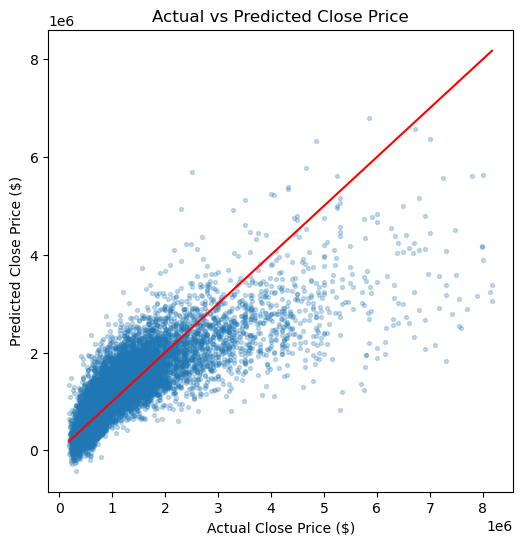

In [13]:
plt.figure(figsize = (6,6))
plt.scatter(y_test, y_pred, alpha = 0.25, s = 8)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = "red"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Actual vs Predicted Close Price")
plt.show()

## Evaluation Summary

The baseline Linear Regression model achieved an R² score of 0.6405 on the held-out test dataset, explaining approximately 64.05% of the variation in residential property close prices.

The evaluation results are summarized below:

- R²: 0.6405
- MAE: USD 368,707.93
- MAPE: 33.8549%
- MdAPE: 25.1820%
- RMSE: USD 586,081.35

The lower MdAPE compared with the MAPE indicates that a relatively small number of properties experienced much larger percentage prediction errors. Likewise, the RMSE being noticeably higher than the MAE suggests the presence of several large absolute prediction errors, likely associated with high-value properties.

Overall, the baseline Linear Regression model provides a useful benchmark for future comparison with more advanced machine learning models capable of capturing nonlinear relationships and complex feature interactions.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship